# Model performance

💡 **Environment:** `clamp-analyses`  

In [1]:
from pathlib import Path
import time
import json
import subprocess
import numpy as np
import pandas as pd
import pickle
from pyprojroot import here
import yaml
import matplotlib.pyplot as plt

In [13]:
with open(here("config.yaml"), "r") as f:
    config = yaml.safe_load(f)

model_colors = config['MODEL_COLORS']

In [3]:
timing_dir = here("output/model_performance/gtex")

# Load PKL files
timings = {}
for fp in sorted(timing_dir.glob("*.pkl")):
    with open(fp, "rb") as f:
        timings[fp.stem] = pickle.load(f)

# Load RDS files via Rscript
rds_files = sorted(timing_dir.glob("*.rds"))
if rds_files:
    r_code = f'''
    library(jsonlite)
    files <- list.files("{timing_dir}", pattern="[.]rds$", full.names=TRUE)
    result <- list()
    for (f in files) {{
        result[[basename(f)]] <- as.list(readRDS(f))
    }}
    cat(toJSON(result, auto_unbox=TRUE))
    '''
    r_result = subprocess.run(["Rscript", "-e", r_code], capture_output=True, text=True)
    rds_data = json.loads(r_result.stdout)
    for fname, vals in rds_data.items():
        stem = fname.replace(".rds", "")
        timings[stem] = vals

print(f"Loaded {len(timings)} timing files from {timing_dir}")
print(sorted(timings.keys()))

Loaded 9 timing files from /home/msubirana/Documents/pivlab/clamp-analyses/output/model_performance/gtex
['CLAMPbase_time_minutes', 'CLAMPfull_BP_time_minutes', 'GenomicSuperSignature_time_minutes', 'ICA_time_minutes', 'MOFA_FLEX_BASE_time_minutes', 'MOFA_FLEX_BP_time_minutes', 'PCA_time_minutes', 'SVD_time_minutes', 'flashier_time_minutes']


In [4]:
timings

{'ICA_time_minutes': {'run1': 19.5200675090154,
  'run2': 18.57447829246521,
  'run3': 18.130145064989726},
 'MOFA_FLEX_BP_time_minutes': {'run1': 533.1914184014003,
  'run2': 526.1577870885532,
  'run3': 590.3642619291942},
 'PCA_time_minutes': {'run1': 0.8889898856480917,
  'run2': 0.9169437050819397,
  'run3': 0.8915667374928792},
 'CLAMPbase_time_minutes': {'run1': 3.6211, 'run2': 3.2741, 'run3': 3.3568},
 'CLAMPfull_BP_time_minutes': {'run1': 13.5438,
  'run2': 13.3887,
  'run3': 13.1554},
 'flashier_time_minutes': {'run1': 942.3346,
  'run2': 1079.1785,
  'run3': 1337.3895},
 'GenomicSuperSignature_time_minutes': {'run1': 27.7838,
  'run2': 26.0591,
  'run3': 28.0163},
 'MOFA_FLEX_BASE_time_minutes': {'run1': 187.7816,
  'run2': 182.2709,
  'run3': 173.8102},
 'SVD_time_minutes': {'run1': 510.3514, 'run2': 507.2705, 'run3': 485.3173}}

## Extract per-model time values

In [5]:
def stem_to_model(stem: str) -> str:
    suffix = "_time_minutes"
    return stem[:-len(suffix)] if stem.endswith(suffix) else stem

datasets = {}
for stem, obj in timings.items():
    model = stem_to_model(stem)
    if isinstance(obj, dict):
        vals = [v for v in obj.values() if isinstance(v, (int, float, np.number))]
        if vals:
            datasets[model] = np.asarray(vals, dtype=float)

# CLAMP = SVD + CLAMPbase + CLAMPfull_BP
clamp_parts = ["SVD", "CLAMPbase", "CLAMPfull_BP"]
if all(p in datasets for p in clamp_parts):
    datasets["CLAMP"] = sum(datasets[p] for p in clamp_parts)
    for p in clamp_parts:
        del datasets[p]

if not datasets:
    raise ValueError("No timing files found.")

## Timing plot

In [10]:
datasets

{'ICA': array([19.52006751, 18.57447829, 18.13014506]),
 'MOFA_FLEX_BP': array([533.1914184 , 526.15778709, 590.36426193]),
 'PCA': array([0.88898989, 0.91694371, 0.89156674]),
 'flashier': array([ 942.3346, 1079.1785, 1337.3895]),
 'GenomicSuperSignature': array([27.7838, 26.0591, 28.0163]),
 'MOFA_FLEX_BASE': array([187.7816, 182.2709, 173.8102]),
 'CLAMP': array([527.5163, 523.9333, 501.8295])}

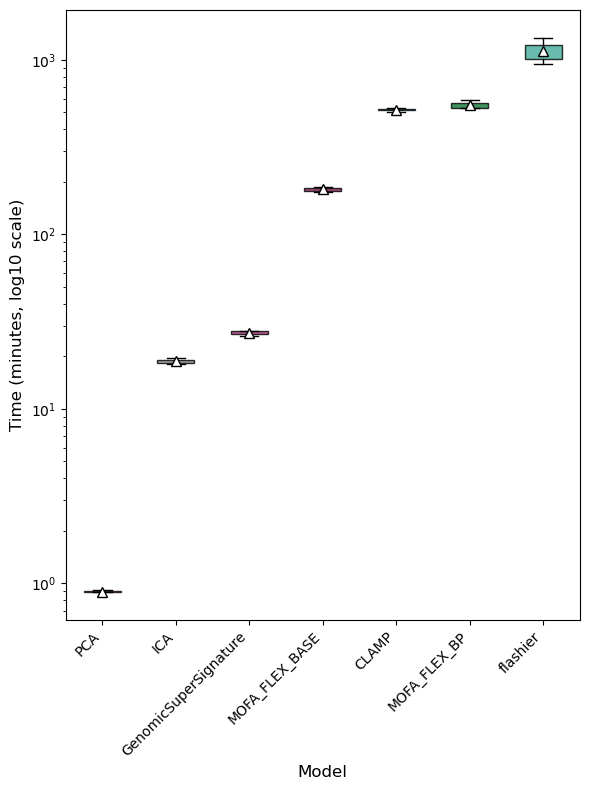

In [ ]:
maxes = {name: float(np.max(arr)) for name, arr in datasets.items()}
ordered_names = sorted(maxes, key=lambda n: maxes[n], reverse=False)

data = [datasets[name].astype(float) for name in ordered_names]
labels = ordered_names

fig, ax = plt.subplots(figsize=(6, 8))

box = ax.boxplot(
    data,
    showmeans=True,
    patch_artist=True,
    medianprops={"visible": False},
    meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 7}
)

key_map = {
    "MOFA_FLEX_BP": "MOFA-FLEX_BP",
    "MOFA_FLEX_BASE": "MOFA-FLEX_base",
    "flashier": "Flashier",
    "CLAMP": "CLAMP_BP"
}

for patch, label in zip(box["boxes"], labels):
    yaml_key = key_map.get(label, label)
    color = model_colors.get(yaml_key, "#888888") 
    
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_alpha(0.8)

ax.set_yscale("log", base=10)
ax.set_ylabel("Time (minutes, log10 scale)", fontsize=12)
ax.set_xlabel("Model", fontsize=12)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()